In [12]:
import pandas as pd

df_feature_importance = pd.read_csv('../output/Anomaly_delirium_Revised/FI_permutation_importance.csv')
print(df_feature_importance.shape)

df_feature_importance

(385, 5)


,patient_id,window_start,anomaly_date,feature,importance
0,1fbe4,2019-04-28,2019-05-08,entropy_rate,-0.018133
1,1fbe4,2019-04-28,2019-05-08,early_warning_score,-0.001232
2,1fbe4,2019-04-28,2019-05-08,sleep_quality_score,-0.004112
3,1fbe4,2019-04-28,2019-05-08,agitation_counts,0.000000
4,1fbe4,2019-04-28,2019-05-08,uti_happen,-0.015323
...,...,...,...,...,...
380,ec812,2019-06-12,2019-06-22,entropy_rate,0.016793
381,ec812,2019-06-12,2019-06-22,early_warning_score,0.000000
382,ec812,2019-06-12,2019-06-22,sleep_quality_score,0.013874
383,ec812,2019-06-12,2019-06-22,agitation_counts,0.000000


In [13]:
counts = df_feature_importance.groupby('patient_id')['window_start'].nunique()
keep = counts[counts > 5].index
df_filtered = df_feature_importance[df_feature_importance['patient_id'].isin(keep)]
df_filtered['importance'] = -df_filtered['importance']
df_filtered


,patient_id,window_start,anomaly_date,feature,importance
0,1fbe4,2019-04-28,2019-05-08,entropy_rate,0.018133
1,1fbe4,2019-04-28,2019-05-08,early_warning_score,0.001232
2,1fbe4,2019-04-28,2019-05-08,sleep_quality_score,0.004112
3,1fbe4,2019-04-28,2019-05-08,agitation_counts,-0.000000
4,1fbe4,2019-04-28,2019-05-08,uti_happen,0.015323
...,...,...,...,...,...
345,c5785,2019-06-18,2019-06-28,entropy_rate,0.025062
346,c5785,2019-06-18,2019-06-28,early_warning_score,0.009549
347,c5785,2019-06-18,2019-06-28,sleep_quality_score,0.010774
348,c5785,2019-06-18,2019-06-28,agitation_counts,-0.000000


In [14]:

rename_map = {
    'entropy_rate': 'entropy rate',
    'early_warning_score': 'early warning score',
    'sleep_quality_score': 'sleep quality score',
    'agitation_counts': 'agitation counts',
    'uti_happen': 'uti counts',
}

df_filtered['feature'] = df_filtered['feature'].replace(rename_map)

df_filtered

,patient_id,window_start,anomaly_date,feature,importance
0,1fbe4,2019-04-28,2019-05-08,entropy rate,0.018133
1,1fbe4,2019-04-28,2019-05-08,early warning score,0.001232
2,1fbe4,2019-04-28,2019-05-08,sleep quality score,0.004112
3,1fbe4,2019-04-28,2019-05-08,agitation counts,-0.000000
4,1fbe4,2019-04-28,2019-05-08,uti counts,0.015323
...,...,...,...,...,...
345,c5785,2019-06-18,2019-06-28,entropy rate,0.025062
346,c5785,2019-06-18,2019-06-28,early warning score,0.009549
347,c5785,2019-06-18,2019-06-28,sleep quality score,0.010774
348,c5785,2019-06-18,2019-06-28,agitation counts,-0.000000


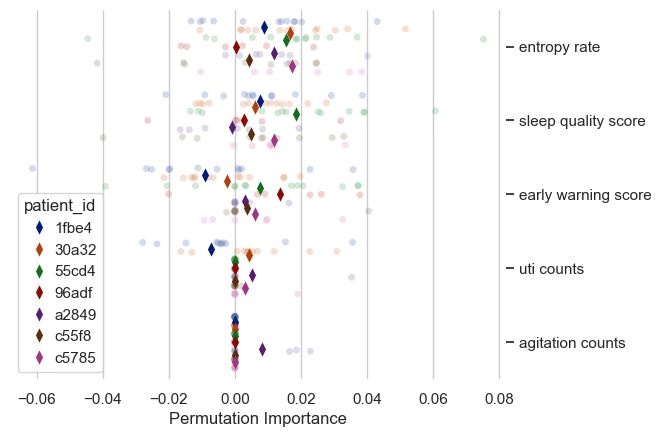

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.set_theme(style="whitegrid")
feature_order = [
    'entropy rate',
    'sleep quality score',
    'early warning score',

    'uti counts',
    'agitation counts'

]

# Initialize the figure
f, ax = plt.subplots()
sns.despine(bottom=True, left=True)

# Show each observation with a scatterplot
sns.stripplot(
    data=df_filtered, x="importance", y="feature", hue="patient_id",order=feature_order,
    dodge=True, alpha=.25, zorder=1, legend=False,
)

# Show the conditional means, aligning each pointplot in the
# center of the strips by adjusting the width allotted to each
# category (.8 by default) by the number of hue levels
sns.pointplot(
    data=df_filtered, x="importance", y="feature", hue="patient_id",order=feature_order,
    dodge=.8 - .8 / 3, palette="dark", errorbar=None,
    markers="d", markersize=4, linestyle="none",
)

# Improve the legend
sns.move_legend(
    ax, loc="lower left", ncol=1, frameon=True, columnspacing=1, handletextpad=0,
)
ax.set_ylabel("")
ax.yaxis.tick_right()
ax.set_xlabel("Permutation Importance")
plt.savefig('../output/Anomaly_delirium_Revised/stripplot_importance.png', dpi=300, bbox_inches="tight")

In [7]:
df_filtered.patient_id.unique()



<StringArray>
['1fbe4', '30a32', '55cd4', '96adf', 'a2849', 'c55f8', 'c5785']
Length: 7, dtype: str

In [8]:
df_feature_importance.patient_id.unique()

<StringArray>
['1fbe4', '30a32', '55cd4', '93c14', '96adf', 'a2849', 'c55f8', 'c5785',
 'c8574', 'e2472', 'ec812']
Length: 11, dtype: str